In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")

In [3]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [4]:
print(df.head())
print(f"Anzahl Datenpunkte: {len(df)}")
print(f"Spalten: {df.columns.tolist()}")

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Anzahl Datenpunkte: 144
Spalten: ['Month', 'Passengers']


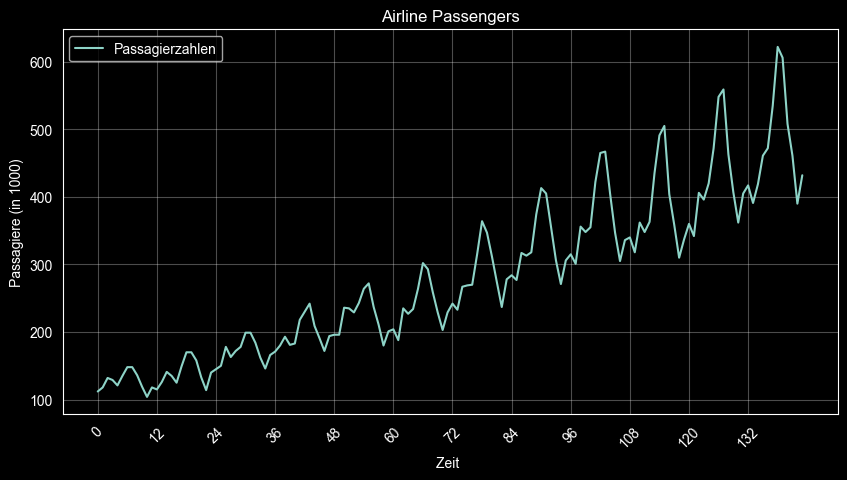

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['Passengers'], label='Passagierzahlen')
plt.title('Airline Passengers')
plt.xlabel('Zeit ')
plt.ylabel('Passagiere (in 1000)')
plt.xticks(range(0, len(df), 12), rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [6]:
def create_data(dataframe, look_back=3):
    varX, vary = [], []
    data = dataframe['Passengers'].values

    for i in range(len(data) - look_back):
        window = data[i : (i + look_back)]
        varX.append(window)
        vary.append(data[i + look_back])

    return np.array(varX), np.array(vary)

X, y = create_data(df, look_back=3)

print("X:")
print(X[:5])
print("y:")
print(y[:5])
print(f"Gesamtanzahl Beispiele: {len(X)}")

X:
[[112 118 132]
 [118 132 129]
 [132 129 121]
 [129 121 135]
 [121 135 148]]
y:
[129 121 135 148 148]
Gesamtanzahl Beispiele: 141


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


test_predictions = model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_predictions)

print(f"Test MAE: {test_mae:.2f} Passagiere")
print(f"Das Modell liegt im Schnitt {test_mae:.0f} Passagiere daneben.")

Test MAE: 58.71 Passagiere
Das Modell liegt im Schnitt 59 Passagiere daneben.


In [8]:
last_window = df['Passengers'].values[-3:]

last_window_2d = last_window.reshape(1, -1)

prediction_jan_1961 = model.predict(last_window_2d)

print(f"Januar 1961: {prediction_jan_1961[0]}")

Januar 1961: 429.01
